# Análise espacial — Violência contra as mulheres no RS

Camada 3 da pipeline: autocorrelação espacial sobre a taxa por 100 mil habitantes
(`outputs/tables/violencia_anual_municipio_taxa.csv`), cruzada com a malha geográfica
dos municípios do RS. A lógica de cada análise vive em `src/fetch_malha_municipios.py`
e `src/analysis/{mapa_choropleth,autocorrelacao_espacial,clusters_lisa}.py` — este
notebook só chama essas funções e visualiza os resultados, sem reimplementar nada aqui.

**Fonte da malha geográfica**: API de malhas territoriais do IBGE
(`https://servicodados.ibge.gov.br/api/v3/malhas/estados/43`), UF=43 (Rio Grande do
Sul), resolução "intermediária". Cada polígono da malha só vem identificado por
`codarea` (código IBGE de 7 dígitos) — o join com o nome de município usado nas
planilhas SIP/PROCERGS passa por `outputs/tables/municipio_codigo_ibge.csv` (código
IBGE × nome, também buscado na API do IBGE), não por nome direto.

Duas perguntas, sobre o mesmo período de referência (2021-2025):

1. **Existe** autocorrelação espacial na taxa de cada tipo de crime — municípios de
   taxa alta tendem a ficar perto de outros municípios de taxa alta (ou baixa perto de
   baixa), mais do que se esperaria ao acaso? → **Índice de Moran Global**.
2. Se existe, **onde** estão esses clusters? → **LISA** (Local Indicators of Spatial
   Association).

---

**Índice de Moran Global (I)** resume a autocorrelação espacial numa única estatística
para o estado inteiro: compara o valor de cada município com a média dos seus vizinhos
(aqui, contiguidade de rainha — municípios que compartilham fronteira ou só um
vértice).

- **I > 0**: padrão de cluster — municípios de taxa alta tendem a ter vizinhos de taxa
  alta também (e taxa baixa perto de taxa baixa).
- **I ≈ 0**: padrão espacialmente aleatório, sem relação entre vizinhança e taxa.
- **I < 0**: padrão de "tabuleiro de xadrez" (valores dissimilares alternando no
  espaço) — incomum em dados de criminalidade.

O p-valor reportado vem de um teste de permutação (999 realocações aleatórias da taxa
entre os municípios, malha fixa): mede a chance de observar um I tão extremo quanto o
real só por acaso, sem assumir normalidade.

**LISA (Local Indicators of Spatial Association)** decompõe o Moran Global numa
estatística por município, revelando *onde* os clusters estão. Cada município com
significância local própria (p<0,05, também por permutação) cai numa de quatro
categorias:

- **Alto-Alto**: taxa alta, cercado de vizinhos de taxa alta — um "hot spot".
- **Baixo-Baixo**: taxa baixa, cercado de vizinhos de taxa baixa — um "cold spot".
- **Alto-Baixo** / **Baixo-Alto**: outlier espacial — o município destoa do entorno
  (taxa alta isolada num entorno de taxa baixa, ou o inverso).
- Município sem essa marcação: sem padrão espacial local detectável ali, mesmo que o
  Moran Global do estado como um todo seja significativo.


In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd

from src.analysis import autocorrelacao_espacial, clusters_lisa, mapa_choropleth
from src.fetch_malha_municipios import carregar_malha_com_municipio

# Mesma ordem fixa dos outros dois notebooks (analise_exploratoria.ipynb,
# analise_inferencial.ipynb) -- nunca reciclada por ranking/filtro.
CRIME_ORDER = [
    "Ameaça",
    "Estupro",
    "Feminicídio Consumado",
    "Feminicídio Tentado",
    "Lesão Corporal",
]


## Malha geográfica e join com os dados de violência

Confirma que a malha (por `codarea`, via `municipio_codigo_ibge.csv`) cobre os mesmos
497 municípios que aparecem em `violencia_anual_municipio_taxa.csv`, antes de seguir
para qualquer mapa ou estatística espacial.


In [2]:
malha = carregar_malha_com_municipio()
taxa = pd.read_csv("../outputs/tables/violencia_anual_municipio_taxa.csv")

municipios_malha = set(malha["municipio"])
municipios_taxa = set(taxa["municipio"].unique()) - {"NÃO INFORMADO"}
match = municipios_malha & municipios_taxa

print(f"Municípios na malha geográfica: {len(municipios_malha)}")
print(f"Municípios em violencia_anual_municipio_taxa.csv (exceto NÃO INFORMADO): {len(municipios_taxa)}")
print(f"Match: {len(match)}/{len(municipios_malha)}")

assert len(match) == len(municipios_malha) == len(municipios_taxa) == 497, "join incompleto"


Municípios na malha geográfica: 497
Municípios em violencia_anual_municipio_taxa.csv (exceto NÃO INFORMADO): 497
Match: 497/497


## 1. Distribuição da taxa por município (choropleth)

Taxa acumulada 2021-2025 por 100 mil hab. (soma dos casos / soma da população no
período), um mapa por tipo de crime -- os 5 tipos entram aqui para completude visual,
mas **Feminicídio Consumado e Feminicídio Tentado não têm cluster espacial
estatisticamente significativo** (ver seção 2 abaixo) e por isso não aparecem nos
mapas LISA da seção 3.


Ameaça: salvo em /home/agschafer/projetos/violencia-mulheres-rs/outputs/figures/choropleth_ameaca_2021_2025.png


Estupro: salvo em /home/agschafer/projetos/violencia-mulheres-rs/outputs/figures/choropleth_estupro_2021_2025.png


Feminicídio Consumado: salvo em /home/agschafer/projetos/violencia-mulheres-rs/outputs/figures/choropleth_feminicidio_consumado_2021_2025.png


Feminicídio Tentado: salvo em /home/agschafer/projetos/violencia-mulheres-rs/outputs/figures/choropleth_feminicidio_tentado_2021_2025.png


Lesão Corporal: salvo em /home/agschafer/projetos/violencia-mulheres-rs/outputs/figures/choropleth_lesao_corporal_2021_2025.png


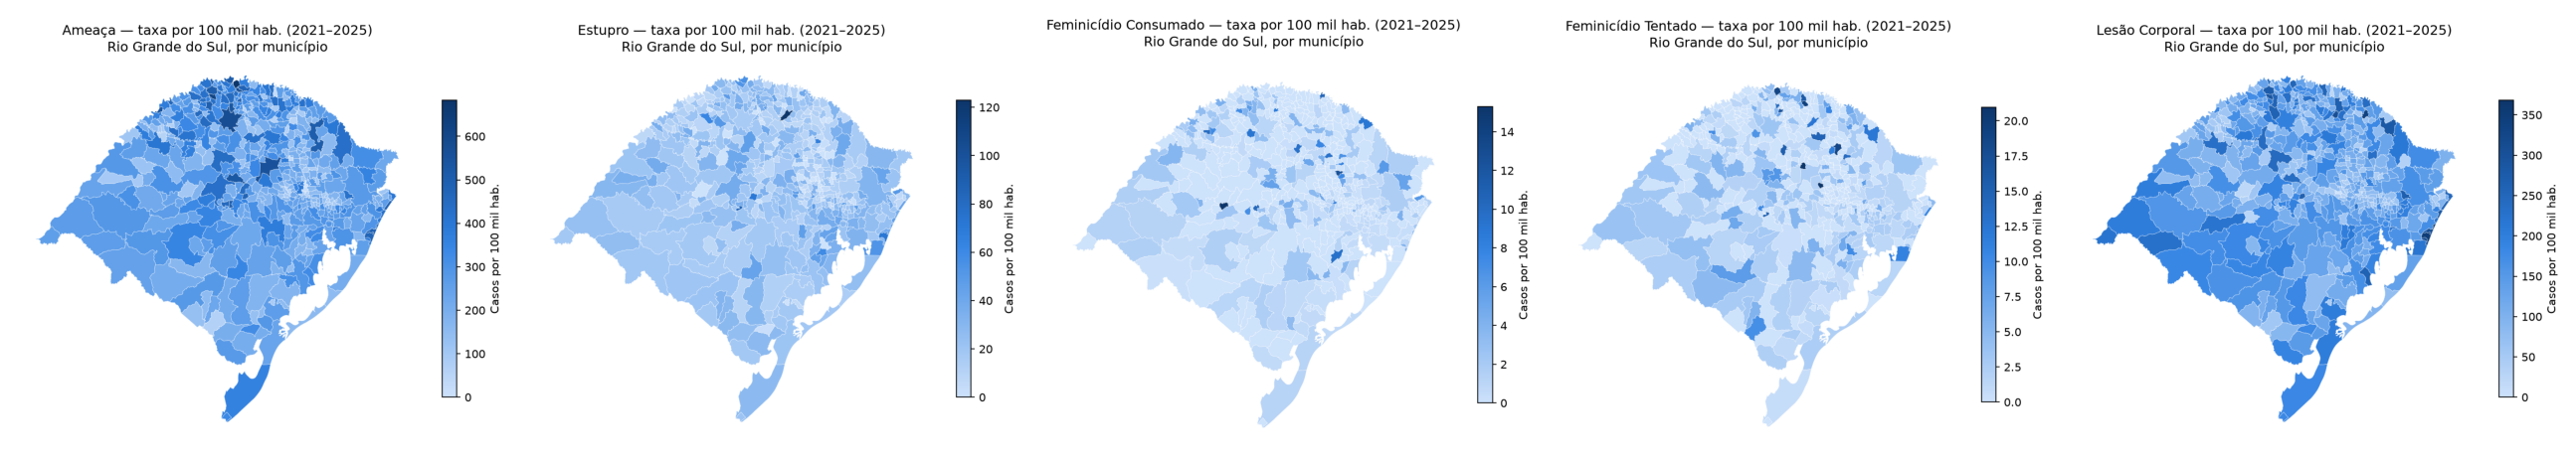

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(26, 6))
for ax, tipo in zip(axes, CRIME_ORDER):
    caminho, _ = mapa_choropleth.gerar_mapa(tipo_crime=tipo)
    ax.imshow(mpimg.imread(caminho))
    ax.axis("off")
    print(f"{tipo}: salvo em {caminho}")

fig.tight_layout()
plt.show()


## 2. Existe autocorrelação espacial? (Índice de Moran Global)

Moran Global para os 5 tipos de crime, mesmo período (2021-2025) e mesma matriz de
pesos espaciais (contiguidade de rainha, 497 municípios, 0 ilhas sem vizinho, média de
5,63 vizinhos/município).


In [4]:
moran_df = autocorrelacao_espacial.comparar_tipos_crime()
moran_df


,tipo_crime,moran_i,ei_esperado_h0,z_sim,p_valor_permutacao,p_valor_normal,significativo_5pct,n_municipios,media_vizinhos,n_ilhas
0,Ameaça,0.307643,-0.002016,11.527223,0.001,3.374401e-29,True,497,5.633803,0
1,Estupro,0.104149,-0.002016,3.972964,0.001,1.202510e-04,True,497,5.633803,0
2,Feminicídio Consumado,-0.001959,-0.002016,-0.058858,0.500,9.983382e-01,False,497,5.633803,0
3,Feminicídio Tentado,0.025986,-0.002016,1.043993,0.139,3.104362e-01,False,497,5.633803,0
4,Lesão Corporal,0.267221,-0.002016,9.776606,0.001,1.798910e-22,True,497,5.633803,0


**Leitura:** Ameaça (I=0,31) e Lesão Corporal (I=0,27) têm autocorrelação espacial
forte; Estupro é significativa mas mais fraca (I=0,10). Feminicídio Consumado (I≈-0,002,
p=0,50) e Feminicídio Tentado (I=0,026, p=0,14) não são distinguíveis de aleatoriedade
espacial a 5% -- esperado para eventos raros, onde a contagem baixa por município
(muitos municípios com 0 casos no período) dilui qualquer padrão geográfico em ruído.


## 3. Onde estão os clusters? (LISA)

Só para os 3 tipos com Moran Global significativo (Ameaça, Estupro, Lesão Corporal —
`clusters_lisa.TIPOS_CRIME_PADRAO`): categoria de cluster local por município, com
significância própria por permutação (999 reamostragens, p<0,05).


Ameaça: salvo em /home/agschafer/projetos/violencia-mulheres-rs/outputs/figures/lisa_ameaca_2021_2025.png -- 110/497 municípios com cluster local significativo


Estupro: salvo em /home/agschafer/projetos/violencia-mulheres-rs/outputs/figures/lisa_estupro_2021_2025.png -- 76/497 municípios com cluster local significativo


Lesão Corporal: salvo em /home/agschafer/projetos/violencia-mulheres-rs/outputs/figures/lisa_lesao_corporal_2021_2025.png -- 102/497 municípios com cluster local significativo


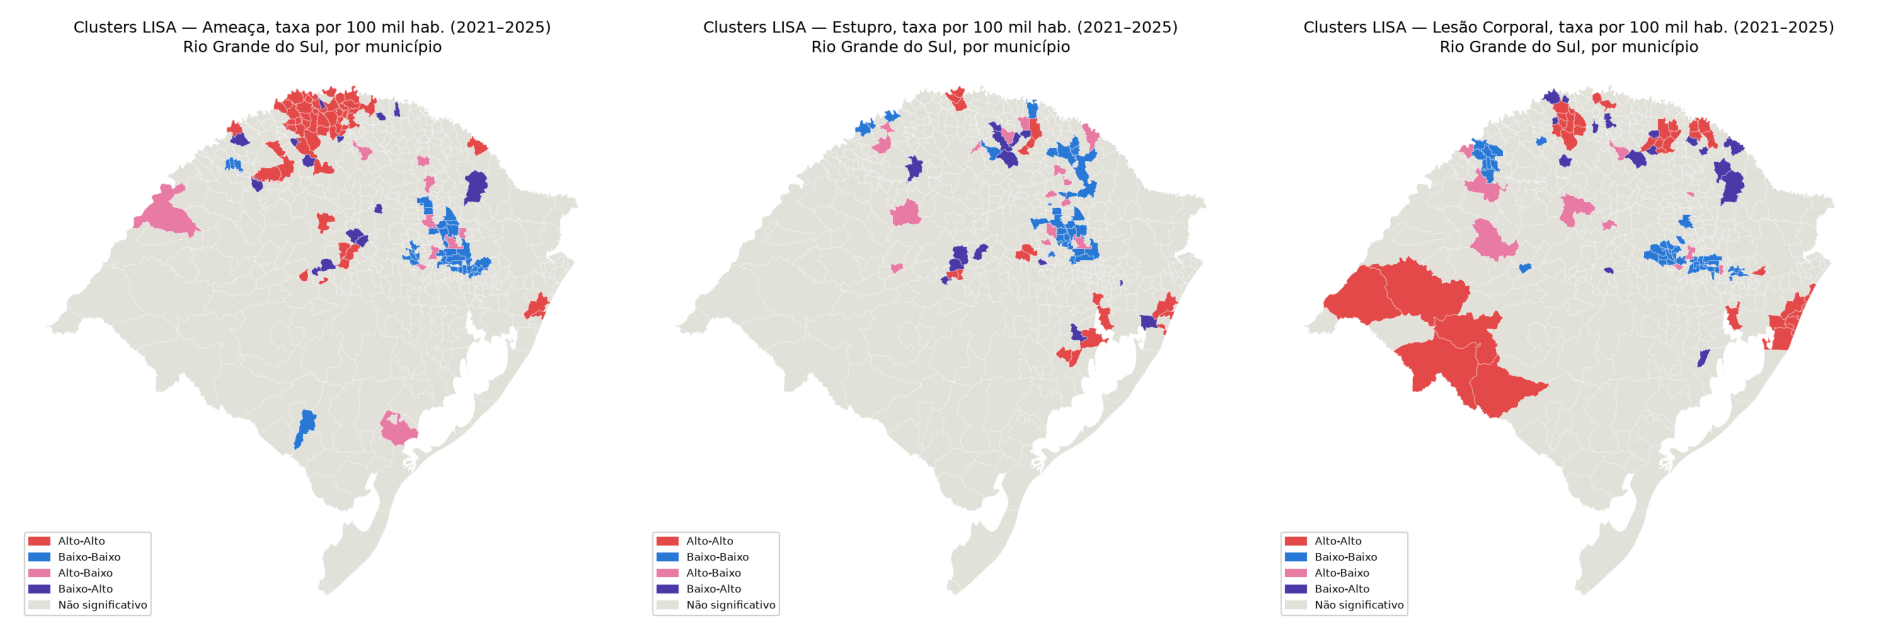

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
for ax, tipo in zip(axes, clusters_lisa.TIPOS_CRIME_PADRAO):
    caminho, gdf_tipo = clusters_lisa.gerar_mapa_lisa(tipo_crime=tipo)
    ax.imshow(mpimg.imread(caminho))
    ax.axis("off")
    n_sig = (gdf_tipo["categoria"] != "Não significativo").sum()
    print(f"{tipo}: salvo em {caminho} -- {n_sig}/{len(gdf_tipo)} municípios com cluster local significativo")

fig.tight_layout()
plt.show()


**Hot spots (Alto-Alto) identificados:**

- **Lesão Corporal** — concentrados no **litoral norte**: Imbé, Cidreira, Balneário
  Pinhal e Tramandaí lideram a taxa entre os hot spots (Moran local I entre 5,6 e 8,4,
  todos p<0,01), com Capão da Canoa e Xangri-lá também no grupo — a mesma faixa de
  municípios turísticos/litorâneos ao norte de Porto Alegre.
- **Ameaça** — concentrados nas **Missões/noroeste**: Iraí, Miraguaí, Ametista do Sul,
  Vicente Dutra e Tenente Portela têm os maiores Moran I locais (3,5 a 7,3, todos
  p<0,01) -- região distinta da de Lesão Corporal, sem sobreposição geográfica.
- **Estupro** — tem hot spots nomeáveis, mas divididos em dois grupos menores em vez de
  um só território contíguo:
  - **Região Metropolitana de Porto Alegre + litoral**: Porto Alegre, Nova Santa Rita,
    Barra do Ribeiro, Cerro Grande do Sul e Sentinela do Sul (RMPA e litoral sul), mais
    Tramandaí, Balneário Pinhal e Osório (litoral norte) -- parcialmente sobreposto ao
    cluster de Lesão Corporal, mas estendendo até a própria capital.
  - **Alto Uruguai/norte**: Erechim, Erebango, Ipiranga do Sul e Frederico Westphalen
    (municípios vizinhos entre si), mais Vicente Dutra -- na mesma região ampla do
    cluster de Ameaça, mas não os mesmos municípios.
  - Os demais (Caiçara, Faxinal do Soturno, Dona Francisca, Boqueirão do Leão,
    Progresso) não formam um terceiro grupo geograficamente contíguo, e aparecem
    isolados no mapa.
